In [1]:
import numpy as np
import setup as stp
import Maxwell2D as Max
import mesh_reader as msh
import matplotlib.pyplot as plt

N = 1

pontos_borda = np.array([11, 21, 41, 81])

erros = []
for n in range(len(pontos_borda)):
    VX, VY, EToV, BCTags = msh.MeshReader2D(f'malhas/h{n}.msh')

    malha = stp.StartUp2D(N,EToV,VX,VY)

    Ez = np.zeros((malha.Np,malha.K),dtype=np.float64)
    Ez = np.sin(malha.x)*np.sin(malha.y)
    Hx = np.zeros((malha.Np,malha.K), dtype=np.float64)
    Hy = np.zeros((malha.Np,malha.K),dtype= np.float64)

    FinalTime = 3 * np.pi * np.sqrt(2)

    Hx, Hy, Ez, pp, t, erro = Max.Maxwell2D(Hx,Hy,Ez,FinalTime,malha,CFL=0.1,pml=False)

    Ez_analitico = np.sin(malha.x)*np.sin(malha.y)*np.cos(np.sqrt(2)*t[-1])

    M = np.linalg.inv(malha.V @ malha.V.T) 

    erro_nodal = Ez - Ez_analitico

    integral_erro_sq = np.sum(malha.J * (erro_nodal * (M @ erro_nodal)))
    En = np.sqrt(integral_erro_sq)

    integral_analitico_sq = np.sum(malha.J * (Ez_analitico * (M @ Ez_analitico)))
    wt = np.sqrt(integral_analitico_sq)

    erro_L2_real = En / wt

    erros.append(erro_L2_real)

Malha carregada com sucesso!
Número de vértices: 121
Número de Elementos (K): 200
Tempo atual: 7.0833e-02 / 1.3329e+01
Tempo atual: 1.4167e-01 / 1.3329e+01
Tempo atual: 2.1250e-01 / 1.3329e+01
Tempo atual: 2.8333e-01 / 1.3329e+01
Tempo atual: 3.5417e-01 / 1.3329e+01
Tempo atual: 4.2500e-01 / 1.3329e+01
Tempo atual: 4.9583e-01 / 1.3329e+01
Tempo atual: 5.6667e-01 / 1.3329e+01
Tempo atual: 6.3750e-01 / 1.3329e+01
Tempo atual: 7.0833e-01 / 1.3329e+01
Tempo atual: 7.7917e-01 / 1.3329e+01
Tempo atual: 8.5000e-01 / 1.3329e+01
Tempo atual: 9.2083e-01 / 1.3329e+01
Tempo atual: 9.9167e-01 / 1.3329e+01
Tempo atual: 1.0625e+00 / 1.3329e+01
Tempo atual: 1.1333e+00 / 1.3329e+01
Tempo atual: 1.2042e+00 / 1.3329e+01
Tempo atual: 1.2750e+00 / 1.3329e+01
Tempo atual: 1.3458e+00 / 1.3329e+01
Tempo atual: 1.4167e+00 / 1.3329e+01
Tempo atual: 1.4875e+00 / 1.3329e+01
Tempo atual: 1.5583e+00 / 1.3329e+01
Tempo atual: 1.6292e+00 / 1.3329e+01
Tempo atual: 1.7000e+00 / 1.3329e+01
Tempo atual: 1.7708e+00 / 1.33

Ordem de Convergência Espacial (k):
De 11 para 21 pontos -> Ordem = 2.53
De 21 para 41 pontos -> Ordem = 2.29
De 41 para 81 pontos -> Ordem = 2.09


Para h = 6.283185e-01 -> erro = 1.04e-01
Para h = 3.141593e-01 -> erro = 1.80e-02
Para h = 1.570796e-01 -> erro = 3.67e-03
Para h = 7.853982e-02 -> erro = 8.64e-04


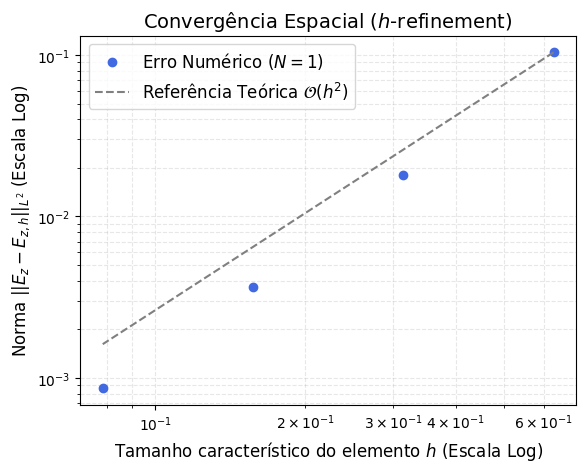

In [ ]:
L_total = 2 * np.pi
h_valores = L_total / (pontos_borda - 1)

erros = np.array(erros) 

print("Ordem de Convergência Espacial (k):")
for i in range(len(h_valores) - 1):
    h_antigo = h_valores[i]
    h_novo = h_valores[i+1]
    
    E_antigo = erros[i]
    E_novo = erros[i+1]
    
    ordem_k = (np.log(E_novo) - np.log(E_antigo)) / (np.log(h_novo) - np.log(h_antigo))
    
    print(f"De {pontos_borda[i]:2d} para {pontos_borda[i+1]:2d} pontos -> Ordem = {ordem_k:.2f}")

print('\n')

for j in range(len(h_valores)):
    print(f'Para h = {h_valores[j]:2e} -> erro = {erros[j]:.2e}')

plt.figure()
plt.loglog(h_valores, erros,'o', color='royalblue', label=r'Erro Numérico ($N=1$)')
plt.xlabel(r"Tamanho característico do elemento $h$ (Escala Log)", fontsize=12)
plt.ylabel(r"Norma $||E_z - E_{z,h}||_{L^2}$ (Escala Log)", fontsize=12)
plt.title(r"Convergência Espacial ($h$-refinement)", fontsize=14)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=12)
plt.show()